In [139]:
import numpy as np
import pandas as pd

In [140]:
df = pd.read_csv('spam.csv',encoding='latin-1')

In [141]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
5131,ham,That sucks. I'll go over so u can do my hair. ...,NaN,NaN,NaN
4822,ham,:-) :-),NaN,NaN,NaN
3610,ham,No. I.ll meet you in the library,NaN,NaN,NaN
4928,spam,Got what it takes 2 take part in the WRC Rally...,NaN,NaN,NaN
1005,ham,Give me a sec to think think about it,NaN,NaN,NaN


#1 Data cleaning

In [142]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 217.8 KB


In [143]:
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)

In [144]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   v1      5572 non-null   str  
 1   v2      5572 non-null   str  
dtypes: str(2)
memory usage: 87.2 KB


In [145]:
#renaming
df.rename(columns={'v1':'target','v2':'text'},inplace=True)
df.sample(5)

,target,text
753,ham,When did you get to the library
1038,ham,"Edison has rightly said, \A fool can ask more ..."
2798,ham,I've told him that i've returned it. That shou...
731,ham,No he didn't. Spring is coming early yay!
2420,ham,Oic... Then better quickly go bathe n settle d...


In [146]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [147]:
df['target'] = encoder.fit_transform(df['target'])

In [148]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [149]:
df.isnull().sum()

target    0
text      0
dtype: int64

In [150]:
#duplicate
df.duplicated().sum()

np.int64(403)

In [151]:
#remove duplicate
df = df.drop_duplicates(keep='first')

In [152]:
df.duplicated().sum()

np.int64(0)

In [153]:
df.shape

(5169, 2)

2.EDA

In [154]:
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

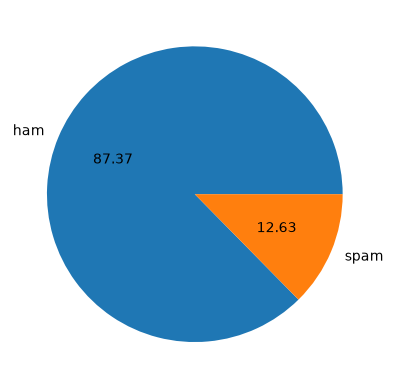

In [155]:
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(),labels=['ham','spam'],autopct="%0.2f")
plt.show()

# Data imbalnce 

In [156]:
!pip install nltk
import nltk

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: C:\Users\rocky\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [157]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\rocky\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [158]:
df['num_chracters'] = df['text'].apply(len)

In [159]:
df.head()

,target,text,num_chracters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [160]:
nltk.download('all')  
df['text'].apply(lambda x: len(nltk.word_tokenize(x)))


[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to
[nltk_data]    |     C:\Users\rocky\AppData\Roaming\nltk_data...
[nltk_data]    |   Package abc is already up-to-date!
[nltk_data]    | Downloading package alpino to
[nltk_data]    |     C:\Users\rocky\AppData\Roaming\nltk_data...
[nltk_data]    |   Package alpino is already up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     C:\Users\rocky\AppData\Roaming\nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger is already up-
[nltk_data]    |       to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     C:\Users\rocky\AppData\Roaming\nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_eng is already
[nltk_data]    |       up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     C:\Users\rocky\AppData\Roaming\nltk_data...
[

0       24
1        8
2       37
3       13
4       15
        ..
5567    35
5568     9
5569    15
5570    27
5571     7
Name: text, Length: 5169, dtype: int64

In [161]:
df['text'].apply(lambda x: nltk.word_tokenize(x))

0       [Go, until, jurong, point, ,, crazy, .., Avail...
1                [Ok, lar, ..., Joking, wif, u, oni, ...]
2       [Free, entry, in, 2, a, wkly, comp, to, win, F...
3       [U, dun, say, so, early, hor, ..., U, c, alrea...
4       [Nah, I, do, n't, think, he, goes, to, usf, ,,...
                              ...                        
5567    [This, is, the, 2nd, time, we, have, tried, 2,...
5568     [Will, Ì_, b, going, to, esplanade, fr, home, ?]
5569    [Pity, ,, *, was, in, mood, for, that, ., So, ...
5570    [The, guy, did, some, bitching, but, I, acted,...
5571                  [Rofl, ., Its, true, to, its, name]
Name: text, Length: 5169, dtype: object

In [162]:
df['num_sentences'] = df['text'].apply(lambda x: len(nltk.sent_tokenize(x)))

In [163]:
df.head()

,target,text,num_chracters,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,2
1,0,Ok lar... Joking wif u oni...,29,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,2
3,0,U dun say so early hor... U c already then say...,49,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,1


In [164]:
# Fix
print(df.columns)

Index(['target', 'text', 'num_chracters', 'num_sentences'], dtype='str')


In [165]:
df['num_words'] = df['text'].apply(lambda x: len(nltk.word_tokenize(x)))


In [166]:
df[['num_chracters', 'num_words', 'num_sentences']].describe()

,num_chracters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [167]:
!pip install seaborn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: C:\Users\rocky\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


<Axes: xlabel='num_chracters', ylabel='Count'>

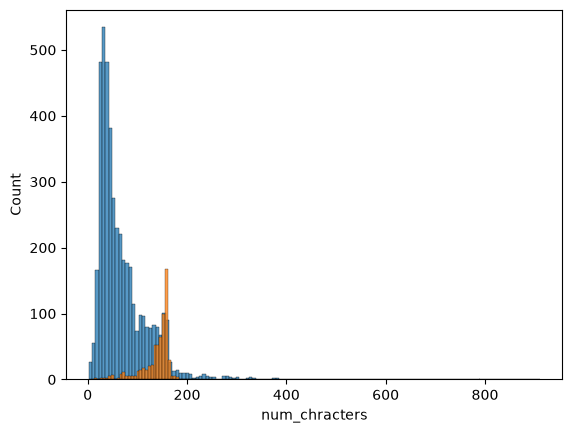

In [168]:
import seaborn as sns
sns.histplot(df[df['target']==0]['num_chracters'])
sns.histplot(df[df['target']==1]['num_chracters'])

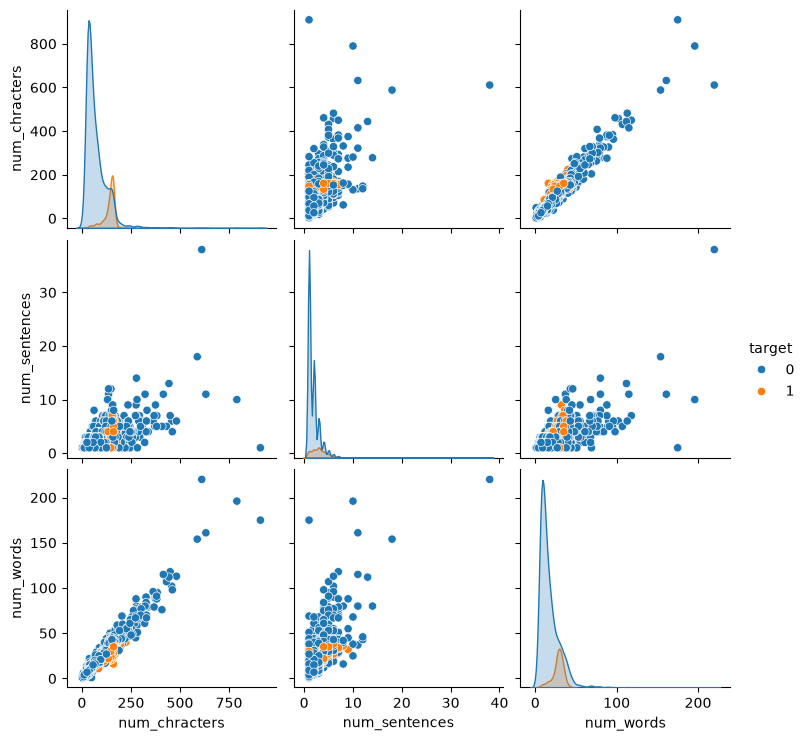

In [169]:
sns.pairplot(df,hue='target')

<Axes: >

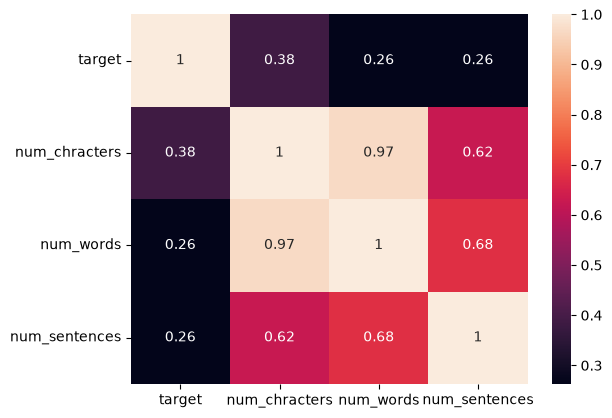

In [170]:
sns.heatmap(df[['target','num_chracters','num_words','num_sentences']].corr(), annot=True)

3.Data Preprocessing

In [171]:
from nltk.stem import PorterStemmer
ps = PorterStemmer()

In [172]:
def transform_text(text):

    text = text.lower()
    

    text = nltk.word_tokenize(text)

    y = []
    for i in text:
        if i.isalnum():
            y.append(i)
    text=y[:]
    
    y.clear()
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)
    
    text=y[:]
    
    y.clear()
    for i in text:
        y.append(ps.stem(i))
    
    return " ".join(y)


In [173]:
from nltk.corpus import stopwords
stopwords.words('english')

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [174]:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [175]:
transform_text('He is crying and when did u go for playing football?')

'cri u go play footbal'

In [176]:
df['text'][2000]

"But i'll b going 2 sch on mon. My sis need 2 take smth."

In [177]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
ps.stem('crying')

'cri'

In [178]:
df['transformed_text'] = df['text'].apply(transform_text)

In [179]:
df.head()

,target,text,num_chracters,num_sentences,num_words,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,2,24,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,2,8,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,2,37,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,1,13,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,1,15,nah think goe usf live around though


In [180]:
from wordcloud import WordCloud
wc = WordCloud(width=500,height=500,min_font_size=10,background_color='white')
spam_wc = wc.generate(df[df['target']==1]['transformed_text'].str.cat(sep=" ") )

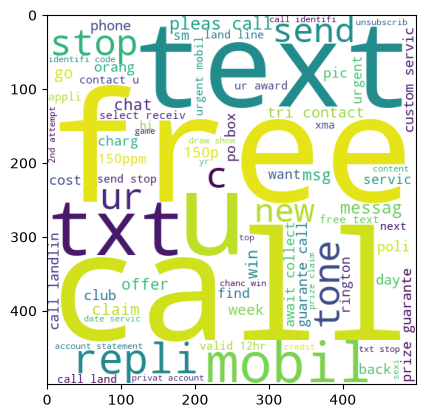

In [181]:
plt.imshow(spam_wc)

In [182]:
ham_wc = wc.generate(df[df['target']==0]['transformed_text'].str.cat(sep=" ") )

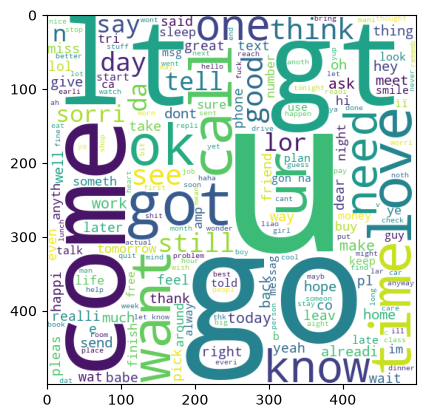

In [183]:
plt.imshow(ham_wc)

In [184]:
spam_corpus = [] 
for msg in df[df['target']==1]['transformed_text'].tolist() :
    for word in msg.split():
        spam_corpus.append(word)

In [185]:
len(spam_corpus)

9939

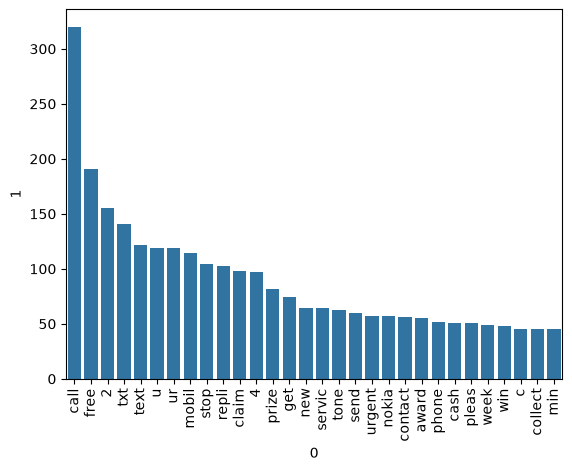

In [186]:
from collections import Counter

spam_df = pd.DataFrame(Counter(spam_corpus).most_common(30))

sns.barplot(x=spam_df[0], y=spam_df[1])
plt.xticks(rotation=90) 
plt.show()

In [187]:
ham_corpus = [] 
for msg in df[df['target']==0]['transformed_text'].tolist() :
    for word in msg.split():
        ham_corpus.append(word)

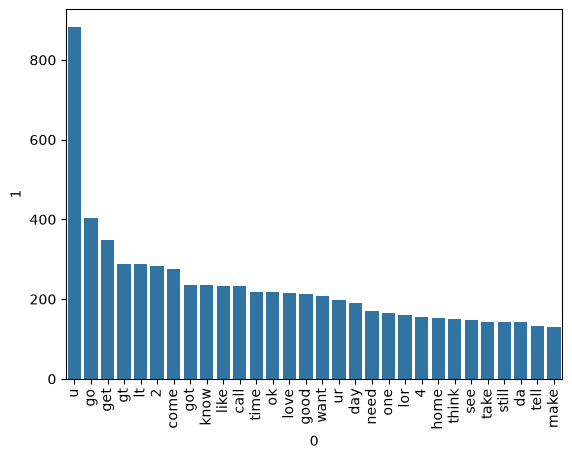

In [188]:
from collections import Counter

ham_df = pd.DataFrame(Counter(ham_corpus).most_common(30))

sns.barplot(x=ham_df[0], y=ham_df[1])
plt.xticks(rotation=90) 
plt.show()

4.Model Building

In [189]:
from sklearn.feature_extraction.text import CountVectorizer , TfidfVectorizer
cv=CountVectorizer()
tfidf = TfidfVectorizer()

In [190]:
X=tfidf.fit_transform(df['transformed_text'])

In [191]:
X.shape

(5169, 6708)

In [192]:
y=df['target'].values

In [193]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=0)

In [194]:
from sklearn.naive_bayes import MultinomialNB,GaussianNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score,recall_score

In [195]:
gnb=GaussianNB()
mnb=MultinomialNB()
bnb=BernoulliNB()

In [196]:
gnb.fit(X_train.toarray(), y_train)
y_pred1 = gnb.predict(X_test.toarray())

print(accuracy_score(y_test, y_pred1))
print(confusion_matrix(y_test, y_pred1))
print(precision_score(y_test, y_pred1))

0.8713733075435203
[[774 111]
 [ 22 127]]
0.5336134453781513


In [197]:
mnb.fit(X_train, y_train)       
y_pred2 = mnb.predict(X_test)    

print(accuracy_score(y_test, y_pred2))
print(confusion_matrix(y_test, y_pred2))
print(precision_score(y_test, y_pred2))

0.9458413926499033
[[885   0]
 [ 56  93]]
1.0


In [198]:
bnb.fit(X_train, y_train)       
y_pred3 = bnb.predict(X_test)    

print(accuracy_score(y_test, y_pred3))
print(confusion_matrix(y_test, y_pred3))
print(precision_score(y_test, y_pred3))

0.9661508704061895
[[881   4]
 [ 31 118]]
0.9672131147540983


In [199]:
#using tfdif - mnb


In [200]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [201]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=42)
abc = AdaBoostClassifier(n_estimators=50, random_state=42)
bc  = BaggingClassifier(n_estimators=50, random_state=42)
etc = ExtraTreesClassifier(n_estimators=50, random_state=42)
gbc = GradientBoostingClassifier(n_estimators=50, random_state=42)
xgb = XGBClassifier(n_estimators=50, random_state=42, eval_metric='logloss')

In [202]:
clfs = {
    'SVC': svc,
    'KN' : knc,  
    'MNB': mnb,  
    'DTC': dtc,
    'LRC': lrc,
    'RFC': rfc,
    'ABC': abc,
    'BC' : bc,
    'ETC': etc,
    'GBC': gbc,
    'XGB': xgb
}

In [203]:
def train_classifier(clfs, X_train, y_train, X_test, y_test):
    clfs.fit(X_train, y_train)  
    y_pred = clfs.predict(X_test) 
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred) 
    return accuracy, precision

In [204]:
train_classifier(svc, X_train, y_train, X_test, y_test)

(0.9680851063829787, 0.9754098360655737)

In [205]:
accuracy_scores=[]
precision_scores=[]

for clf in clfs:
    accuracy, precision = train_classifier(clfs[clf], X_train, y_train, X_test, y_test)
    accuracy_scores.append(accuracy)
    precision_scores.append(precision)
    print(clf, 'Accuracy:', accuracy, 'Precision:', precision)

SVC Accuracy: 0.9680851063829787 Precision: 0.9754098360655737
KN Accuracy: 0.8887814313346228 Precision: 1.0
MNB Accuracy: 0.9458413926499033 Precision: 1.0
DTC Accuracy: 0.9332688588007737 Precision: 0.8703703703703703
LRC Accuracy: 0.9564796905222437 Precision: 0.956140350877193


C:\Users\rocky\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\rocky\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


RFC Accuracy: 0.9671179883945842 Precision: 0.9914529914529915
ABC Accuracy: 0.925531914893617 Precision: 0.875
BC Accuracy: 0.965183752417795 Precision: 0.900709219858156
ETC Accuracy: 0.971953578336557 Precision: 0.9918032786885246
GBC Accuracy: 0.960348162475822 Precision: 0.9736842105263158
XGB Accuracy: 0.971953578336557 Precision: 0.96875


In [206]:
performance_df = pd.DataFrame({'Classifier': clfs.keys(), 'Accuracy': accuracy_scores, 'Precision': precision_scores})
performance_df

,Classifier,Accuracy,Precision
0,SVC,0.968085,0.975410
1,KN,0.888781,1.000000
2,MNB,0.945841,1.000000
3,DTC,0.933269,0.870370
4,LRC,0.956480,0.956140
5,RFC,0.967118,0.991453
6,ABC,0.925532,0.875000
7,BC,0.965184,0.900709
8,ETC,0.971954,0.991803
9,GBC,0.960348,0.973684


In [208]:
performance_df = pd.DataFrame({
    'Algorithm': clfs.keys(),
    'Accuracy' : accuracy_scores,
    'Precision': precision_scores
})

performance_df1 = performance_df.melt(
    id_vars='Algorithm',
    value_vars=['Accuracy', 'Precision']
)

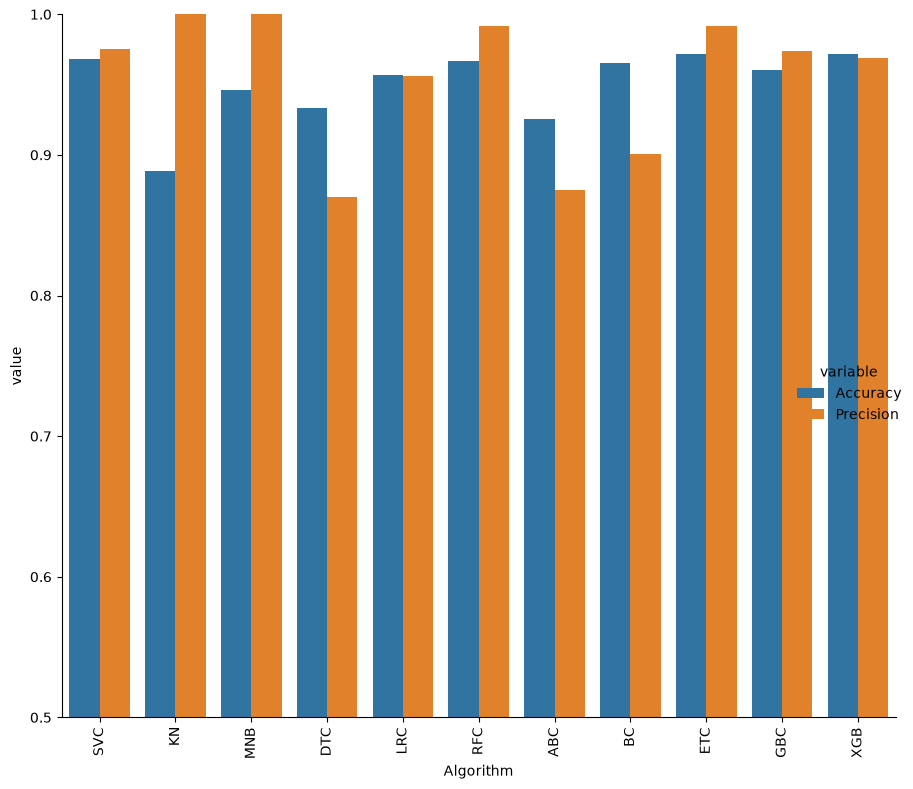

In [209]:
sns.catplot(x='Algorithm', y='value',
            hue='variable', data=performance_df1, kind='bar', height=8)  # height 5→8
plt.ylim(0.5, 1.0)
plt.xticks(rotation='vertical')
plt.tight_layout()  
plt.show()

#model improve 

In [ ]:
temp_df=pd.DataFrame({'Algorithm': clfs.keys(), 'Accuracy': accuracy_scores, 'Precision': precision_scores})